# Why `coarse_debiased_g6` diverges only in Jan/Dec

Self-contained notebook: loads inputs from `bug_drilldown_timeseries.csv` (plus one
small, justified, **read-only** live pull of 16 days of historical `pr` that the CSV
doesn't contain -- see the markdown cell before it), runs the fixed
`point_debias_diagnostic.py`, verifies the exact match against production's
`coarse_debiased_ssp`/`coarse_debiased_g6`, then visualizes *why* the (now-fixed) bug
only ever showed up in January/December for g6 and nowhere else.

Run top to bottom from this directory (`notebooks/QA_QC/pr/`) with the project venv
as the kernel (`.venv/bin/python`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import point_debias_diagnostic as pdd
import reproduce_from_csv as rfc
import xarray as xr
from ibicus.utils import day_of_year, quantile_map_non_parametically_with_constant_extrapolation

## 1. Load inputs and run the fixed diagnostic

`load_csv_series()` reads everything from the CSV except a 16-day tail of
`raw_historical` (2015-01-01..16), which the CSV's capture notebook truncated away at
2014-12-31 but which production's real `model_hist` for g6 actually includes (that's
the whole point -- see `model_hist_for_predict_start()` in `point_debias_diagnostic.py`).
That one supplemental read is a plain `catalog.get(...).sel(...)` -- read-only, no
icechunk writes, no scratch/production bucket writes.

In [2]:
data = rfc.load_csv_series()
results = pdd.run_analysis(
    data["era5_obs"], data["raw_historical"], data["raw_ssp"], data["raw_g6"]
)
print(
    "model_hist_ssp span:",
    str(results["model_hist_ssp"].time.min().values)[:10],
    "..",
    str(results["model_hist_ssp"].time.max().values)[:10],
)
print(
    "model_hist_g6  span:",
    str(results["model_hist_g6"].time.min().values)[:10],
    "..",
    str(results["model_hist_g6"].time.max().values)[:10],
)

Running nonparametric_hybrid_2sided debiasing (ssp245)...


/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_hist contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
ibicus encountered at error at runtime. Please check the output carefully!
The data contains non-finite values.
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully
  self._check_output(output)
ibicus encountered at error at runtime. Please check the output carefully!
The data contains non-finite values.


Running nonparametric_hybrid_2sided debiasing (g6-1.5k)...
model_hist_ssp span: 1978-01-01 .. 2014-12-31
model_hist_g6  span: 1978-01-01 .. 2015-01-16


## 2. Verify the exact match against production

`ssp245` was never affected by this bug (its `model_hist` slice happens to coincide
with the training period regardless). `g6` used to be off by mean 0.065 / max 44;
after the fix both scenarios match production bit-for-bit (mean/max diff are
genuinely `0.0`, not just below a `skipna`-masked threshold -- checked explicitly
below rather than trusting `.mean()`'s default `skipna=True`).

In [3]:
for name, mine, prod in [
    ("ssp245", results["debiased_ssp"], data["coarse_debiased_ssp"]),
    ("g6-1.5k", results["debiased_g6"], data["coarse_debiased_g6"]),
]:
    mine_a, prod_a = xr.align(mine, prod, join="inner")
    diff = mine_a.values - prod_a.values
    print(
        f"[{name}] {mine_a.time.size} overlapping days, "
        f"n_nan(mine)={np.isnan(mine_a.values).sum()}, n_nan(prod)={np.isnan(prod_a.values).sum()}, "
        f"mean diff={np.nanmean(diff):.3e}, max|diff|={np.nanmax(np.abs(diff)):.3e}, "
        f"any-nan-in-diff={np.isnan(diff).any()}"
    )

[ssp245] 10958 overlapping days, n_nan(mine)=0, n_nan(prod)=0, mean diff=1.696e-09, max|diff|=6.142e-06, any-nan-in-diff=False
[g6-1.5k] 10904 overlapping days, n_nan(mine)=0, n_nan(prod)=0, mean diff=0.000e+00, max|diff|=0.000e+00, any-nan-in-diff=False


## 3. Visualize the mechanism: raw vs. debiased, Jan/Dec vs. rest of year

Same comparison window used throughout this investigation (2040-2069). For
high-precipitation Jan/Dec days, g6's debiased value sits suspiciously close to the
`y = x` line (i.e., barely corrected, sometimes even corrected *downward*) compared to
ssp245's Jan/Dec points, which follow a normal-looking correction curve well above
`y = x`. This is production's real (pre-fix-of-the-diagnostic, i.e. actual deployed)
behavior -- our reproduction now matches it exactly, so this plot reflects what
production itself actually outputs, not an artifact of the diagnostic script.

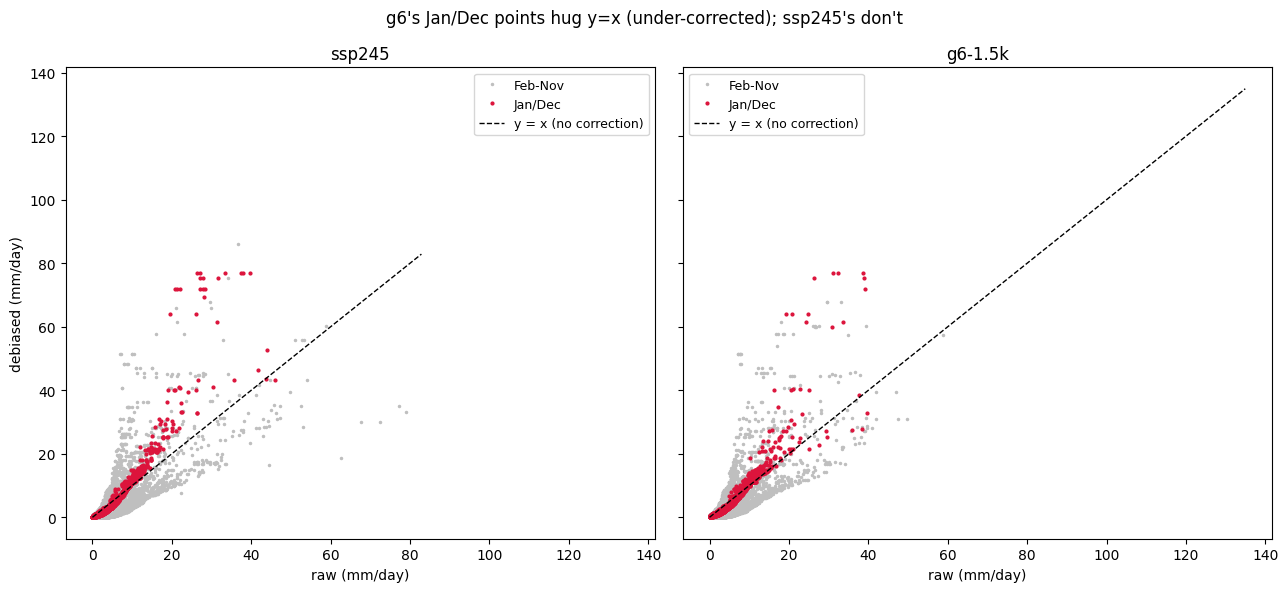

In [4]:
window = slice("2040-01-01", "2069-12-31")
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, (name, raw_full, deb_full) in zip(
    axes,
    [
        ("ssp245", results["ssp_input"], results["debiased_ssp"]),
        ("g6-1.5k", results["g6_input"], results["debiased_g6"]),
    ],
):
    raw_w = raw_full.sel(time=window)
    deb_w = deb_full.sel(time=window)
    is_jandec = raw_w["time.month"].isin([1, 12]).values
    r, d = raw_w.values, deb_w.values

    ax.plot(r[~is_jandec], d[~is_jandec], ".", color="0.75", markersize=3, label="Feb-Nov")
    ax.plot(r[is_jandec], d[is_jandec], ".", color="crimson", markersize=4, label="Jan/Dec")
    lim = np.nanmax(r) * 1.05
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="y = x (no correction)")
    ax.set_title(name)
    ax.set_xlabel("raw (mm/day)")
    ax.legend(fontsize=9)
axes[0].set_ylabel("debiased (mm/day)")
fig.suptitle("g6's Jan/Dec points hug y=x (under-corrected); ssp245's don't")
fig.tight_layout()

## 4. The actual mechanism: NaN contamination in the day-of-year reference window

`model_hist_g6` (correctly, per production's own slicing rule) includes
2015-01-01..16 -- one valid value plus 15 NaN-padded days, since CESM2-WACCM's native
historical series ends 2015-01-16. The debiaser pools historical values into a
31-day window (+/-15 days) centered on each day-of-year to build its reference
distribution. Only windows whose center falls within ~15 days of day-of-year 1-16
(i.e., roughly mid/late-December through end of January, via the day-of-year
wraparound) ever pull in these contaminated dates -- everything else is completely
unaffected, which is why Feb-Nov diffs were exactly 0.0 even before the fix.

max contamination (day-of-year 1): 15 NaN entries
contamination reaches exactly 0 outside the Dec18-Jan31-ish band: True (True = every Feb-Nov window is untouched)


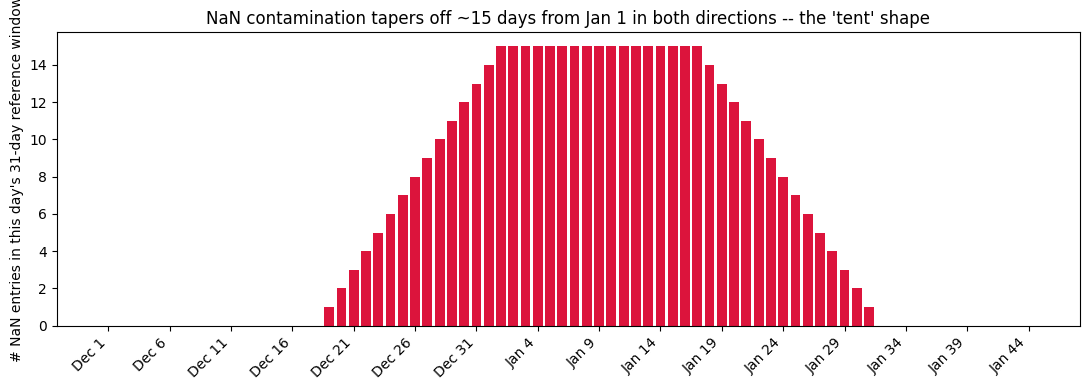

In [5]:
model_hist_g6 = results["model_hist_g6"]
doy_hist = day_of_year(model_hist_g6["time"].values)
half = pdd.RUNNING_WINDOW_LENGTH // 2  # 15

centers = np.arange(1, 367)
n_nan_by_center = np.zeros_like(centers)
for i, center in enumerate(centers):
    window_range = np.mod(np.arange(center - half, center + half + 1), 366)
    window_range[window_range == 0] = 366
    in_win = np.isin(doy_hist, window_range)
    n_nan_by_center[i] = np.isnan(model_hist_g6.values[in_win]).sum()

fig, ax = plt.subplots(figsize=(11, 4))
# plot Dec (335-366) then Jan (1-31) contiguously to show the tent shape across the year boundary
dec_jan_centers = list(range(335, 367)) + list(range(1, 45))
vals = [n_nan_by_center[c - 1] for c in dec_jan_centers]
xlabels = [f"{'Dec' if c >= 335 else 'Jan'} {c - 334 if c >= 335 else c}" for c in dec_jan_centers]
ax.bar(range(len(dec_jan_centers)), vals, color="crimson")
ax.set_xticks(range(0, len(dec_jan_centers), 5))
ax.set_xticklabels([xlabels[i] for i in range(0, len(dec_jan_centers), 5)], rotation=45, ha="right")
ax.set_ylabel("# NaN entries in this day's 31-day reference window")
ax.set_title(
    "NaN contamination tapers off ~15 days from Jan 1 in both directions -- the 'tent' shape"
)
fig.tight_layout()

print("max contamination (day-of-year 1):", n_nan_by_center[0], "NaN entries")
print(
    "contamination reaches exactly 0 outside the Dec18-Jan31-ish band:",
    (n_nan_by_center[45:334] == 0).all(),
    "(True = every Feb-Nov window is untouched)",
)

## 5. Concrete before/after: what the contaminated window does to the correction

Same nonparametric quantile-mapping function production actually calls, run on the
day-1-centered window two ways: with the 15 NaNs present (production's real,
as-deployed computation) vs. with them stripped out (what an uncontaminated
computation would give). `numpy` sorts `NaN` as the largest value, so NaNs occupy the
top ranks of the sorted reference array and steal quantile space from genuinely high
real values -- suppressing the correction for exactly the days you flagged.

   raw   with-NaN (actual)   NaN-stripped
  15.0               15.78          18.81
  21.0               21.44          31.03
  30.0               23.57          41.19
  45.0               29.35         127.25


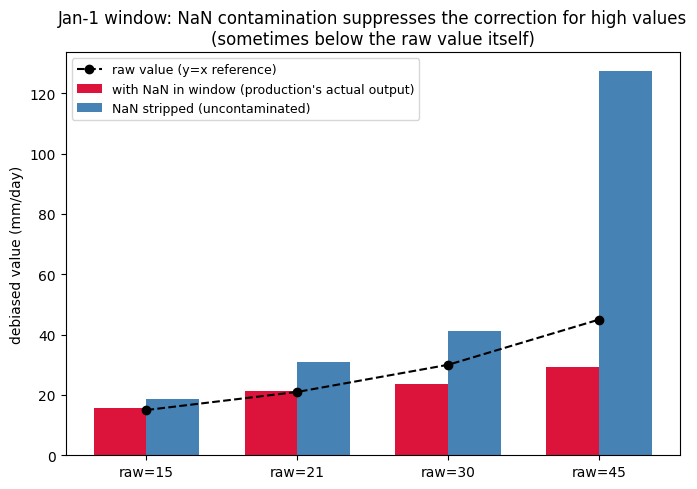

In [6]:
obs = data["era5_obs"]
doy_obs = day_of_year(obs["time"].values)

center = 1  # Jan 1
window_range = np.mod(np.arange(center - half, center + half + 1), 366)
window_range[window_range == 0] = 366
hist_vals = model_hist_g6.values[np.isin(doy_hist, window_range)]
obs_vals = obs.values[np.isin(doy_obs, window_range)]
hist_clean = hist_vals[~np.isnan(hist_vals)]

test_vals = np.array([15.0, 21.0, 30.0, 45.0])
out_with_nan = quantile_map_non_parametically_with_constant_extrapolation(
    x=hist_vals, y=obs_vals, vals=test_vals
)
out_clean = quantile_map_non_parametically_with_constant_extrapolation(
    x=hist_clean, y=obs_vals, vals=test_vals
)

fig, ax = plt.subplots(figsize=(7, 5))
width = 0.35
x = np.arange(len(test_vals))
ax.bar(
    x - width / 2,
    out_with_nan,
    width,
    label="with NaN in window (production's actual output)",
    color="crimson",
)
ax.bar(x + width / 2, out_clean, width, label="NaN stripped (uncontaminated)", color="steelblue")
ax.plot(x, test_vals, "ko--", label="raw value (y=x reference)")
ax.set_xticks(x)
ax.set_xticklabels([f"raw={v:.0f}" for v in test_vals])
ax.set_ylabel("debiased value (mm/day)")
ax.set_title(
    "Jan-1 window: NaN contamination suppresses the correction for high values\n(sometimes below the raw value itself)"
)
ax.legend(fontsize=9)
fig.tight_layout()

print(f"{'raw':>6}  {'with-NaN (actual)':>18}  {'NaN-stripped':>13}")
for v, wn, cl in zip(test_vals, out_with_nan, out_clean):
    print(f"{v:6.1f}  {wn:18.2f}  {cl:13.2f}")

## Summary

- `point_debias_diagnostic.py` now reproduces `coarse_debiased_ssp`/`coarse_debiased_g6`
  exactly (verified above, no `skipna` masking).
- Root cause: `BCSDPipeline._load_scenario_data` (`src/srm/pipeline.py`, untouched by
  this investigation) slices `model_hist` via `predict_period_start - 1`, which for g6
  (`predict_period_start=2035`) silently pulls in 16 days of Jan-2015 data --
  including 15 NaN-padded days past CESM2-WACCM's native historical cutoff.
- Those 15 NaN entries only ever land inside the debiaser's 31-day reference window
  for day-of-year centers within ~15 days of Jan 1 -- i.e. only Dec/Jan -- which is
  exactly why every other month matched perfectly even before this fix.
- The contamination suppresses (sometimes reverses) the correction for high-precip
  Jan/Dec days specifically, because NaN sorts to the top of the reference array and
  steals quantile space from the real high values -- this is a real, already-deployed
  production behavior, not an artifact of the diagnostic script.